In [15]:
import numpy as np
import matplotlib.pyplot as plt

N = 10
STEPS = 10_000
RUNS = 2_000
EPS = 0.1
ALPHA = 0.1
WALK_STD = 0.01

In [16]:
def eps_greedy(Q, eps):
    if np.random.rand() < eps:
        return np.random.randint(len(Q))
    return np.argmax(Q)

In [17]:
def run_bandit(method="sample_average"):
    Q_true = np.zeros(N)
    Q_est = np.zeros(N)
    action_counts = np.zeros(N)

    rewards = np.zeros(STEPS)
    optimal_actions = np.zeros(STEPS)

    for step in range(STEPS):
        # Nonstationary random walk
        Q_true += np.random.normal(0, WALK_STD, size=N)

        optimal_action = np.argmax(Q_true)

        action = eps_greedy(Q_est, EPS)

        reward = np.random.normal(Q_true[action], 1)

        rewards[step] = reward
        optimal_actions[step] = action == optimal_action

        if method == "sample_average":
            action_counts[action] += 1
            Q_est[action] += (1 / action_counts[action]) * (reward - Q_est[action])
        
        elif method == "constant_alpha":
            Q_est[action] += ALPHA * (reward - Q_est[action])
        
    return rewards, optimal_actions

In [18]:
sample_avg_rewards = np.zeros(STEPS)
sample_avg_optimal = np.zeros(STEPS)

alpha_rewards = np.zeros(STEPS)
alpha_optimal = np.zeros(STEPS)

for run in range(RUNS):
    r, o = run_bandit(method="sample_average")
    sample_avg_rewards += r
    sample_avg_optimal += o

    r, o = run_bandit(method="constant_alpha")
    alpha_rewards += r
    alpha_optimal += o

sample_avg_rewards /= RUNS
sample_avg_optimal = sample_avg_optimal / RUNS * 100

alpha_rewards /= RUNS
alpha_optimal = alpha_optimal / RUNS * 100

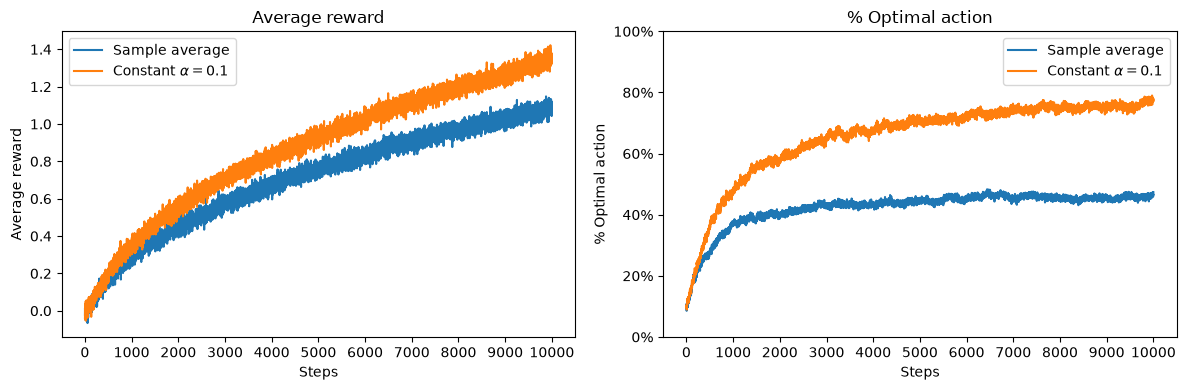

In [19]:
x = np.arange(1, STEPS + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title("Average reward")
ax[0].plot(x, sample_avg_rewards, label="Sample average")
ax[0].plot(x, alpha_rewards, label=r"Constant $\alpha=0.1$")
ax[0].set_xlabel("Steps")
ax[0].set_ylabel("Average reward")
ax[0].set_xticks(np.arange(0, STEPS + 1, 1000))
ax[0].legend()

ax[1].set_title("% Optimal action")
ax[1].plot(x, sample_avg_optimal, label="Sample average")
ax[1].plot(x, alpha_optimal, label=r"Constant $\alpha=0.1$")
ax[1].set_xlabel("Steps")
ax[1].set_ylabel("% Optimal action")
ax[1].set_xticks(np.arange(0, STEPS + 1, 1000))

yticks = np.arange(0, 101, 20)
ax[1].set_yticks(yticks)
ax[1].set_yticklabels([f"{p}%" for p in yticks])
ax[1].set_ylim(0, 100)
ax[1].legend()

plt.tight_layout()
plt.show()